## WEEK 1 -  Core ML That Actually Matters in Industry

In [176]:
# 17-02-2026

In [ ]:
#Train_test split

In [177]:
import seaborn as sns

In [178]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [179]:
from sklearn.model_selection import train_test_split

In [180]:
X = df.drop('smoker',axis = 1)
y = df['smoker']

In [181]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [182]:
# k fold cross validation
# use to assesing performance of model

In [183]:
from sklearn.datasets import make_classification
import pandas as pd
X, y = make_classification(n_samples = 50,
                                       n_features = 5,
                                       n_informative = 5,
                                       n_redundant = 0,
                                       n_classes = 2,
                                       weights = [0.51, .49])

In [184]:
y

array([1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0])

In [185]:
import numpy as np
def kfold_indices(data, k):
    fold_size = len(data) // k
    indices = np.arange(len(data))
    folds = []
    for i in range(k):
        test_indices = indices[i * fold_size: (i + 1) * fold_size]
        train_indices = np.concatenate([indices[:i * fold_size], indices[(i + 1) * fold_size:]])
        folds.append((train_indices, test_indices))
    return folds

# Define the number of folds (K)
k = 5

# Get the fold indices
fold_indices = kfold_indices(X, k)

In [186]:
fold_indices[0]

(array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
        27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,
        44, 45, 46, 47, 48, 49]),
 array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]))

In [187]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [188]:
model = LogisticRegression()

In [189]:
scores = []
for train_indices,test_indices in fold_indices:
    X_train,y_train = X[train_indices],y[train_indices]
    X_test,y_test = X[test_indices],y[test_indices]

    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)

    fold_score = accuracy_score(y_test,y_pred)
    scores.append(fold_score)

    mean_accuracy = np.mean(scores)
print(f"K-Fold cross validation Scores:{scores}")
print(f"Mean Accuracy: {mean_accuracy}")

K-Fold cross validation Scores:[0.9, 0.8, 0.3, 0.7, 0.9]
Mean Accuracy: 0.72


In [190]:
df.head(1)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2


In [191]:
#check data imbalance or not

In [192]:
new = df['time'].value_counts(normalize=True)

In [193]:
new

time
Dinner    0.721311
Lunch     0.278689
Name: proportion, dtype: float64

In [194]:
# Feature scaling
#18-02-2026

In [195]:
import matplotlib.pyplot as plt

<function matplotlib.pyplot.show(close=None, block=None)>

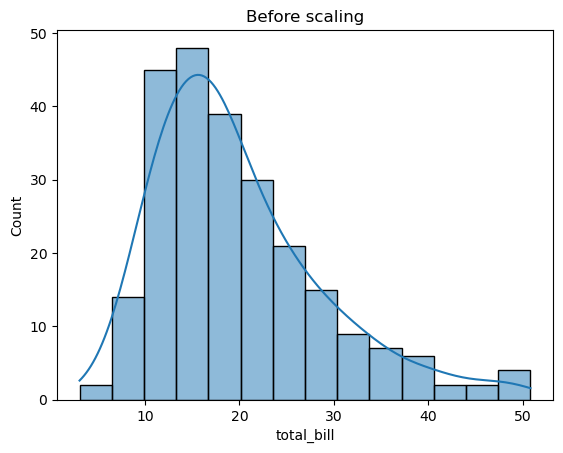

In [196]:
sns.histplot(df['total_bill'],kde=True)
plt.title('Before scaling')
plt.show                                                               

In [197]:
from sklearn.preprocessing import MinMaxScaler

In [198]:
scaler = MinMaxScaler()

In [199]:
scaled_bill = scaler.fit_transform(df[['total_bill']])

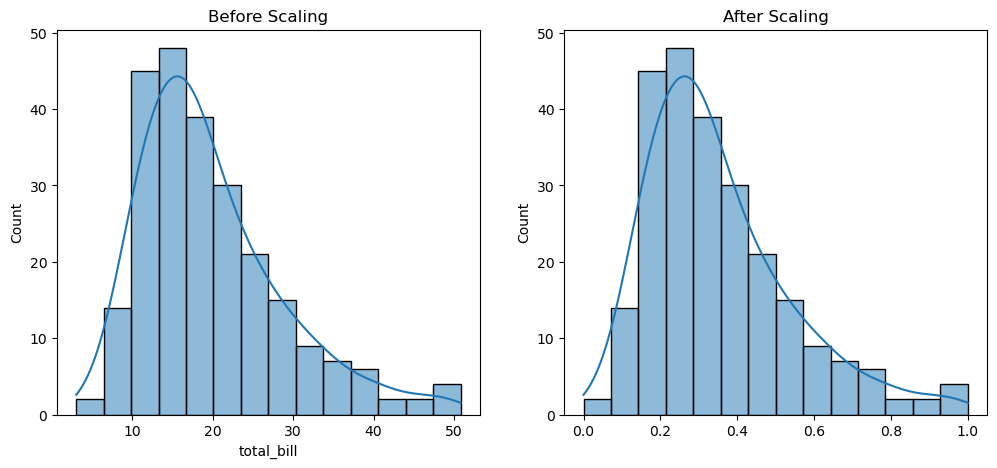

<Figure size 640x480 with 0 Axes>

In [200]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['total_bill'], kde=True)
plt.title('Before Scaling')

plt.subplot(1,2,2)
sns.histplot(scaled_bill.ravel(),kde = True)
plt.title('After Scaling')
plt.show()


plt.tight_layout()

In [201]:
# Handle Imbalance Dataset

In [202]:
data = df.copy()

In [203]:
df.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [204]:
X = data.drop('smoker',axis=1)

In [205]:
y = data['smoker']

In [206]:
from sklearn.model_selection import train_test_split

In [207]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [208]:
from collections import Counter

c = Counter(y_train)
c

Counter({'No': 120, 'Yes': 75})

In [209]:
# Undersampling
# it takes sample from majority class and balance that sample with minority class untill it balanced

In [210]:
from imblearn.under_sampling import RandomUnderSampler

In [211]:
rus = RandomUnderSampler()

In [212]:
X_train_res,y_train_res = rus.fit_resample(X_train,y_train)

In [213]:
d = Counter(y_train_res)
d

Counter({'No': 75, 'Yes': 75})

In [214]:
# Oversampling
# it copies or naive sampling from minority class and generate synthetic sample to balance with majority class

In [215]:
a = np.array([[1,2],[2,1],[1,1],[2,2],[3,1],[8,8],[9,9],    # Minority class (label=1)
              [8,9],[9,8],[8,8],[9,9],[7,8],[8,8],[9,9],])   # Majority class (label=0)

b = np.array([1,1,1,1,1,1,1,1,0,0, 0,0,0,0])

Counter(b)

Counter({np.int64(1): 8, np.int64(0): 6})

In [216]:
#SMOTE (Synthetic minority oversampling Technique)

In [217]:
from imblearn.over_sampling import SMOTE

In [218]:
sm = SMOTE(sampling_strategy=1, random_state=1)
# SAMPLING-STRATEGY :
# 1 -> BALANCE :: minority and majority class at same level(1:1)
# 0.5 -> minority class will be 50% of majority
# 2 -> minority class will be 200%(double) of majority

In [219]:
X_train_sm,y_train_sm = sm.fit_resample(a,b)

In [220]:
Counter(y_train_sm)

Counter({np.int64(1): 8, np.int64(0): 8})

In [318]:
# Exercise 2:

In [315]:
#Before and after using SMOTE

In [317]:
print(f"Before SMOTE :{Counter(b)}")
print(f"After SMOTE :{Counter(y_train_sm)}")

Before SMOTE :Counter({np.int64(1): 8, np.int64(0): 6})
After SMOTE :Counter({np.int64(1): 8, np.int64(0): 8})


In [221]:
# Hybrid Method

In [222]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [223]:
df1 = sns.load_dataset('diamonds')
df1.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [224]:
X = df1.drop('color',axis = 1)
y = df1['color']

In [225]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size =0.2,random_state = 42)

In [226]:
Counter(y_train)

Counter({'G': 9015,
         'E': 7863,
         'F': 7644,
         'H': 6707,
         'D': 5413,
         'I': 4274,
         'J': 2236})

In [227]:
# one-hot encoding
# Categorical data -> NUmerical data

In [228]:
X_train.head()

,carat,cut,clarity,depth,table,price,x,y,z
26546,2.01,Good,SI2,58.1,64.0,16231,8.23,8.19,4.77
9159,1.01,Very Good,SI2,60.0,60.0,4540,6.57,6.49,3.92
14131,1.10,Premium,VS2,62.5,58.0,5729,6.59,6.54,4.10
15757,1.50,Good,SI2,61.5,65.0,6300,7.21,7.17,4.42
24632,1.52,Very Good,VS1,62.1,57.0,12968,7.27,7.32,4.53


In [229]:
X_train = pd.get_dummies(X_train, drop_first=True)  
X_train

,carat,depth,table,price,x,y,z,cut_Premium,cut_Very Good,cut_Good,cut_Fair,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
26546,2.01,58.1,64.0,16231,8.23,8.19,4.77,False,False,True,False,False,False,False,False,False,True,False
9159,1.01,60.0,60.0,4540,6.57,6.49,3.92,False,True,False,False,False,False,False,False,False,True,False
14131,1.10,62.5,58.0,5729,6.59,6.54,4.10,True,False,False,False,False,False,False,True,False,False,False
15757,1.50,61.5,65.0,6300,7.21,7.17,4.42,False,False,True,False,False,False,False,False,False,True,False
24632,1.52,62.1,57.0,12968,7.27,7.32,4.53,False,True,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,1.05,62.4,59.0,4975,6.48,6.51,4.05,False,True,False,False,False,False,False,True,False,False,False
44732,0.47,61.0,55.0,1617,5.03,5.01,3.06,False,False,False,False,False,False,True,False,False,False,False
38158,0.33,60.3,58.0,1014,4.49,4.46,2.70,False,True,False,False,False,False,False,False,False,False,False
860,0.90,62.8,59.0,2871,6.13,6.03,3.82,True,False,False,False,False,False,False,False,True,False,False


In [2]:
#Hybrid model (SMOTE + ENN)

In [ ]:
from imblearn.combine import SMOTEENN

In [231]:
sme = SMOTEENN()

In [232]:
X_train_sme,y_train_sme = sme.fit_resample(X_train,y_train)

In [233]:
Counter(y_train_sme)

Counter({'J': 4078,
         'D': 3315,
         'I': 2786,
         'H': 1842,
         'E': 1835,
         'F': 1583,
         'G': 1428})

In [234]:
# Logistic Regression
# 19-02-2026

In [4]:
import numpy as np
a = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(2,5)
a 

array([[ 1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10]])

In [236]:
#spam classifier using LogisticRegression

In [237]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [238]:
emails = [
    "Win Iphone",
    "Get 50% discount",
    "100% placement",
    "Limited Time offer",
    "Congratulations you won lottery",
    "Claim your free gift now",
    "Exclusive deal just for you",
    "Click here to win cash prize",
    "Urgent response needed to claim reward",
    "Buy now and save big",
    "Special promotion ends today",
    "Earn money from home easily",
    "You have been selected for prize",
    "Free entry in contest",
    "Lowest price guaranteed",
    "Act fast limited stock",
    "Get instant loan approval",
    "Hot sale 70% off",
    "Winner claim your reward",
    "Double your income quickly",

    "Your interview is schedule",
    "Tommorrow your meeting schedule",
    "You are invited to Jaipur",
    "Project deadline is tomorrow",
    "Please find attached report",
    "Let's schedule a call",
    "Team meeting at 10 AM",
    "Lunch meeting confirmed",
    "Client presentation nfcoursext week",
    "Reminder for your appointment",
    "Your order has been shipped",
    "Invoice attached for payment",
    "Happy birthday wishes",
    "Family dinner tonight",
    "Can we reschedule the meeting",
    "Interview confirmation email",
    "Your application has been received",
    "See you at the conference",
    "Meeting agenda attached",
    "Travel itinerary for tomorrow"
]

labels = [
    1,1,1,1,1,1,1,1,1,1,
    1,1,1,1,1,1,1,1,1,1,

    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0
]
#1-Spam
#0-Not Spam

In [239]:
vectorizer = CountVectorizer()

In [240]:
x = vectorizer.fit_transform(emails)

In [241]:
print(vectorizer.get_feature_names_out())

['10' '100' '50' '70' 'act' 'agenda' 'am' 'and' 'application'
 'appointment' 'approval' 'are' 'at' 'attached' 'been' 'big' 'birthday'
 'buy' 'call' 'can' 'cash' 'claim' 'click' 'client' 'conference'
 'confirmation' 'confirmed' 'congratulations' 'contest' 'deadline' 'deal'
 'dinner' 'discount' 'double' 'earn' 'easily' 'email' 'ends' 'entry'
 'exclusive' 'family' 'fast' 'find' 'for' 'free' 'from' 'get' 'gift'
 'guaranteed' 'happy' 'has' 'have' 'here' 'home' 'hot' 'in' 'income'
 'instant' 'interview' 'invited' 'invoice' 'iphone' 'is' 'itinerary'
 'jaipur' 'just' 'let' 'limited' 'loan' 'lottery' 'lowest' 'lunch'
 'meeting' 'money' 'needed' 'nfcoursext' 'now' 'off' 'offer' 'order'
 'payment' 'placement' 'please' 'presentation' 'price' 'prize' 'project'
 'promotion' 'quickly' 'received' 'reminder' 'report' 'reschedule'
 'response' 'reward' 'sale' 'save' 'schedule' 'see' 'selected' 'shipped'
 'special' 'stock' 'team' 'the' 'time' 'to' 'today' 'tommorrow' 'tomorrow'
 'tonight' 'travel' 'urgent

In [242]:
x.shape

(40, 121)

In [243]:
#split the data
x_train,x_test,y_train,y_test = train_test_split(x,labels,test_size=0.2,random_state=42)

In [244]:
x_train.shape

(32, 121)

In [245]:
x_train.shape

(32, 121)

In [246]:
#train model
model = LogisticRegression()
model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [247]:
#predict model
y_predict = model.predict(x_test)

In [248]:
y_predict

array([0, 1, 1, 0, 1, 0, 0, 0])

In [249]:
print(f'Accuracy:{accuracy_score(y_test,y_predict)}')

Accuracy:0.75


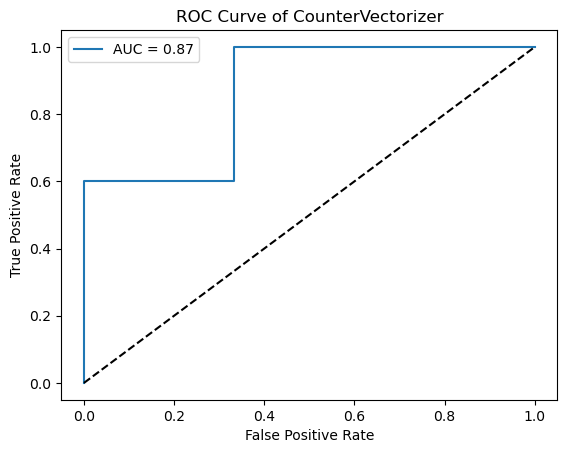

In [250]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities for class 1 (spam)
y_prob = model.predict_proba(x_test)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.2f}")
plt.plot([0,1], [0,1], "k--")  # diagonal
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of CounterVectorizer")
plt.legend()
plt.show()


In [251]:
from sklearn.metrics import f1_score

In [252]:
# countvectorizer F1 SCORE
print(f"f1 score:{f1_score(y_test,y_predict)}")

f1 score:0.75


In [253]:
# NEW ENTRY EXAMPLE

In [254]:
new =["Greeting from Aspire softserv regarding interview"]

In [255]:
new_x = vectorizer.transform(new)

In [256]:
new_x.shape

(1, 121)

In [257]:
pred = model.predict(new_x)

In [14]:
a = float(input("a:"))
if a>=1:
    print(1)
else:
    
    print(0)

a: 0.25


0


In [20]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Sample text data
corpus = [
    "The cat sat on the mat.",
    "The dog is in the house."
]

# Initialize both vectorizers
count_vectorizer = CountVectorizer()
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the data
count_matrix = count_vectorizer.fit_transform(corpus)
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

# Display the vectorized representation
print("CountVectorizer Matrix:\n", count_matrix.toarray())
print("TfidfVectorizer Matrix:\n", tfidf_matrix.toarray())

# Reverse transformation to get back the original text format
count_reversed = count_vectorizer.inverse_transform(count_matrix)
tfidf_reversed = tfidf_vectorizer.inverse_transform(tfidf_matrix)

# Display the reversed text
print("\nReversed Text from CountVectorizer:")
for doc in count_reversed:
    print(" ".join(doc))

print("\nReversed Text from TfidfVectorizer:")
for doc in tfidf_reversed:
    print(" ".join(doc))

CountVectorizer Matrix:
 [[1 0 0 0 0 1 1 1 2]
 [0 1 1 1 1 0 0 0 2]]
TfidfVectorizer Matrix:
 [[0.40740124 0.         0.         0.         0.         0.40740124
  0.40740124 0.40740124 0.57973867]
 [0.         0.40740124 0.40740124 0.40740124 0.40740124 0.
  0.         0.         0.57973867]]

Reversed Text from CountVectorizer:
the cat sat on mat
the dog is in house

Reversed Text from TfidfVectorizer:
mat on sat cat the
house in is dog the


In [258]:
pred 
# 0 -> Not Spam
# 1 -> Spam

array([0])

In [259]:
# USING TF-IDF VECTORIZER(term frequency-inverse documnet frequency)
# It’s a way to convert text into numbers while giving more importance to words that actually matter.
# it also takes the importance of a words into account.

In [260]:
emails_tf = [
    # 20 Spam (1)
    "Win a brand new car today",
    "Get 70% off on all products",
    "Claim your free vacation now",
    "Congratulations! You are a winner",
    "Limited offer: Buy one get one free",
    "Earn $5000 working from home",
    "Exclusive prize for lucky users",
    "Click here to unlock your reward",
    "Urgent: Respond to claim your gift",
    "Lowest prices on electronics today",
    "Hot deals: Save big now",
    "Double your income in one week",
    "Free entry to the lucky draw",
    "Get rich quick with this plan",
    "Special discount just for you",
    "Immediate loan approval available",
    "Claim your free voucher today",
    "Winner! Your reward is waiting",
    "Act fast to get limited bonus",
    "Cash prize waiting to be claimed",

    # 20 Not Spam (0)
    "Team meeting rescheduled to Monday",
    "Your flight itinerary for next week",
    "Project update: please review attached files",
    "Lunch with the client confirmed",
    "Reminder: submit the report by today",
    "Your subscription has been renewed",
    "Can we move the meeting to 3 PM?",
    "Minutes of the last team meeting attached",
    "Your application status has been updated",
    "Happy anniversary wishes",
    "Conference agenda for tomorrow",
    "Invoice for last month attached",
    "Doctor appointment confirmation",
    "Please review the attached proposal",
    "Family gathering this weekend",
    "Your order has been delivered",
    "Invitation to the company seminar",
    "Weekly performance report attached",
    "Your package is out for delivery",
    "Schedule your interview for next week"
]

labels_tf = [
    # Spam
    1,1,1,1,1,1,1,1,1,1,
    1,1,1,1,1,1,1,1,1,1,

    # Not Spam
    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0
]


In [261]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [262]:
model_tf = LogisticRegression()

In [263]:
vect = TfidfVectorizer()

In [264]:
tf_x = vect.fit_transform(emails_tf)

In [265]:
tf_x.shape

(40, 138)

In [266]:
X_train_tf,X_test_tf,y_train_tf,y_test_tf = train_test_split(tf_x,labels_tf,test_size=0.2,random_state = 42)

In [267]:
X_train_tf.shape

(32, 138)

In [268]:
#train model
model_tf.fit(X_train_tf,y_train_tf)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [269]:
pred_tf = model_tf.predict(X_test_tf)
pred_tf

array([1, 1, 0, 0, 1, 0, 0, 0])

In [270]:
print(f"Accuracy:{accuracy_score(y_test_tf,pred_tf)}")

Accuracy:0.75


In [421]:
from sklearn.metrics import classification_report,accuracy_score


In [272]:
# TF-IDF F1 SCORE
print(f"f1 score:{(f1_score(y_test_tf,pred_tf)):.2f}")

f1 score:0.75


In [273]:
print(classification_report(y_test_tf, pred_tf))

              precision    recall  f1-score   support

           0       0.60      1.00      0.75         3
           1       1.00      0.60      0.75         5

    accuracy                           0.75         8
   macro avg       0.80      0.80      0.75         8
weighted avg       0.85      0.75      0.75         8



In [274]:
x_test.shape

(8, 121)

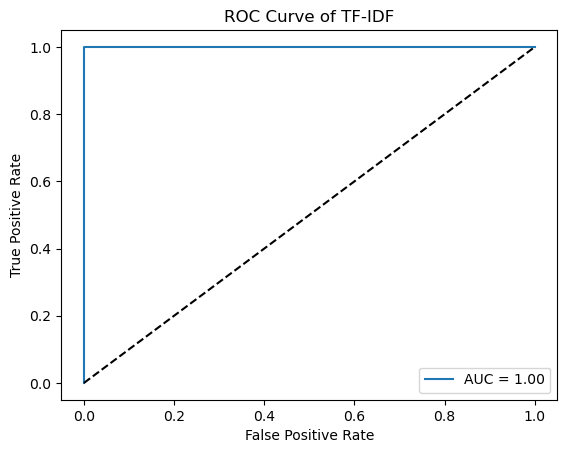

In [275]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities for class 1 (spam)
y_prob_tf = model_tf.predict_proba(X_test_tf)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test_tf, y_prob_tf)

# Plot
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test_tf, y_prob_tf):.2f}")
plt.plot([0,1], [0,1], "k--")  # diagonal
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of TF-IDF")
plt.legend()
plt.show()

In [276]:
# RandomForest

In [277]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [278]:
data = sns.load_dataset('titanic')
# data.head(11)

In [279]:
X = data[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']]
y = data['survived']

In [280]:
X['sex'] = X['sex'].map({'female':0,'male':1})

X['age'] = X['age'].fillna(X['age'].median())

In [281]:
X_train_rf,X_test_rf,y_train_rf,y_test_rf = train_test_split(X,y,test_size = 0.2,random_state=42)

In [282]:
X_train_rf.shape

(712, 6)

In [283]:
model_rf = RandomForestClassifier(n_estimators = 100,random_state = 42)

In [284]:
model_rf.fit(X_train_rf,y_train_rf)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [285]:
y_pred_rf = model_rf.predict(X_test_rf)

In [286]:

# Accuracy using RandomForest
accuracy = accuracy_score(y_test_rf, y_pred_rf)
classification_rep = classification_report(y_test_rf, y_pred_rf)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

Accuracy: 0.80

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [287]:

sample = X_test_rf.iloc[0:1]
prediction = model_rf.predict(sample)

sample_dict = sample.iloc[0].to_dict()
print(f"\nSample Passenger: {sample_dict}")
print(f"Predicted Survival: {'Survived' if prediction == 1 else 'Did Not Survive'}")


Sample Passenger: {'pclass': 3.0, 'sex': 1.0, 'age': 28.0, 'sibsp': 1.0, 'parch': 1.0, 'fare': 15.2458}
Predicted Survival: Did Not Survive


In [288]:
X_test_rf.iloc[:1]

,pclass,sex,age,sibsp,parch,fare
709,3,1,28.0,1,1,15.2458


In [289]:
sample

,pclass,sex,age,sibsp,parch,fare
709,3,1,28.0,1,1,15.2458


In [290]:
sample_dict

{'pclass': 3.0,
 'sex': 1.0,
 'age': 28.0,
 'sibsp': 1.0,
 'parch': 1.0,
 'fare': 15.2458}

In [291]:
prediction[0]

np.int64(0)

In [292]:
X_test_rf

,pclass,sex,age,sibsp,parch,fare
709,3,1,28.0,1,1,15.2458
439,2,1,31.0,0,0,10.5000
840,3,1,20.0,0,0,7.9250
720,2,0,6.0,0,1,33.0000
39,3,0,14.0,1,0,11.2417
...,...,...,...,...,...,...
433,3,1,17.0,0,0,7.1250
773,3,1,28.0,0,0,7.2250
25,3,0,38.0,1,5,31.3875
84,2,0,17.0,0,0,10.5000


In [293]:
sample_l = X_test_rf.iloc[-1:]

In [294]:
prediction = model_rf.predict(sample_l)

In [295]:
print(f"Survival:{'survived' if prediction == 1 else 'Not survived'}")

Survival:survived


In [296]:
#spam classifier using RandomForest

In [297]:
model_sc = RandomForestClassifier()

In [298]:
emails_rf = [
    # 20 Spam (1)
    "Win a brand new car today",
    "Get 70% off on all products",
    "Claim your free vacation now",
    "Congratulations! You are a winner",
    "Limited offer: Buy one get one free",
    "Earn $5000 working from home",
    "Exclusive prize for lucky users",
    "Click here to unlock your reward",
    "Urgent: Respond to claim your gift",
    "Lowest prices on electronics today",
    "Hot deals: Save big now",
    "Double your income in one week",
    "Free entry to the lucky draw",
    "Get rich quick with this plan",
    "Special discount just for you",
    "Immediate loan approval available",
    "Claim your free voucher today",
    "Winner! Your reward is waiting",
    "Act fast to get limited bonus",
    "Cash prize waiting to be claimed",

    # 20 Not Spam (0)
    "Team meeting rescheduled to Monday",
    "Your flight itinerary for next week",
    "Project update: please review attached files",
    "Lunch with the client confirmed",
    "Reminder: submit the report by today",
    "Your subscription has been renewed",
    "Can we move the meeting to 3 PM?",
    "Minutes of the last team meeting attached",
    "Your application status has been updated",
    "Happy anniversary wishes",
    "Conference agenda for tomorrow",
    "Invoice for last month attached",
    "Doctor appointment confirmation",
    "Please review the attached proposal",
    "Family gathering this weekend",
    "Your order has been delivered",
    "Invitation to the company seminar",
    "Weekly performance report attached",
    "Your package is out for delivery",
    "Schedule your interview for next week"
]

labels_rf = [
    # Spam
    1,1,1,1,1,1,1,1,1,1,
    1,1,1,1,1,1,1,1,1,1,

    # Not Spam
    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0
]


In [299]:
X_rf = vectorizer.fit_transform(emails_rf)

In [300]:
X_rf.shape

(40, 138)

In [301]:
#split the dataset
X_train_sc,X_test_sc,y_train_sc,y_test_sc = train_test_split(X_rf,labels_rf,test_size=0.2,random_state=42)

In [302]:
#train model
model_sc.fit(X_train_sc,y_train_sc)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [303]:
y_pred_sc = model_sc.predict(X_test_sc)

In [304]:
y_pred_sc

array([1, 1, 0, 0, 1, 0, 0, 0])

In [ ]:
# unseen data

In [305]:
# Single example
new = ["Congratulation win"]
new_sc = vectorizer.transform(new)

In [306]:
new_sc.shape

(1, 138)

In [307]:
prediction_sc = model_sc.predict(new_sc)

In [308]:
prediction_sc

array([1])

In [309]:
print(f"F1 score :{f1_score(y_test_sc,y_pred_sc)}")

F1 score :0.75


In [ ]:
# Exercise 1:

In [310]:
# SpamClassifier (Logreg Vs RandomForest)

In [311]:
print("Classification report of Spam classifier using LogisticRegression")
print(classification_report(y_test_tf, pred_tf))

Classification report of Spam classifier using LogisticRegression
              precision    recall  f1-score   support

           0       0.60      1.00      0.75         3
           1       1.00      0.60      0.75         5

    accuracy                           0.75         8
   macro avg       0.80      0.80      0.75         8
weighted avg       0.85      0.75      0.75         8



In [312]:
print("Classification report of Spam classifier using RndomForestClassifier")
print(f"{classification_report (y_test_rf, y_pred_rf)}")

Classification report of Spam classifier using RndomForestClassifier
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



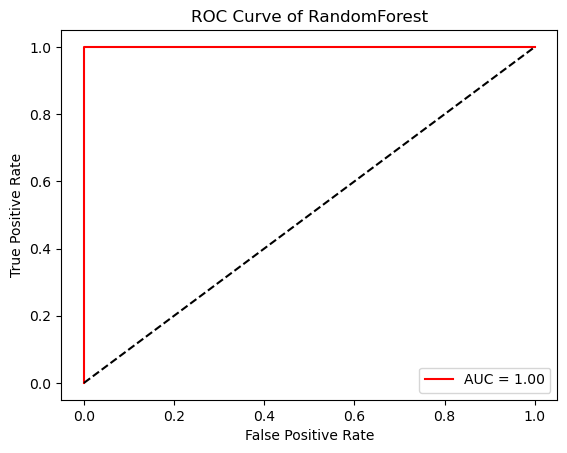

In [313]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities for class 1 (spam)
y_prob_sc = model_sc.predict_proba(X_test_sc)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test_sc, y_prob_sc)

# Plot
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test_sc, y_prob_sc):.2f}",color="red")
plt.plot([0,1], [0,1], "k--")  # diagonal
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of RandomForest")
plt.legend()
plt.show()

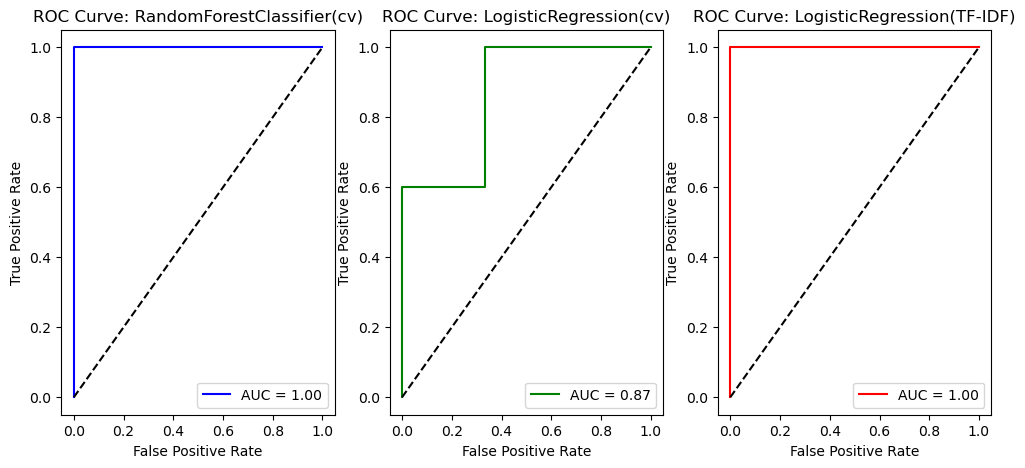

In [314]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# RandomForest
y_prob_sc = model_sc.predict_proba(X_test_sc)[:, 1]
fpr_sc, tpr_sc, _ = roc_curve(y_test_sc, y_prob_sc)
auc_sc = roc_auc_score(y_test_sc, y_prob_sc)

# LogisticRegression
y_prob_cv = model.predict_proba(x_test)[:, 1]
fpr_cv, tpr_cv, _ = roc_curve(y_test, y_prob_cv)
auc_cv = roc_auc_score(y_test, y_prob_cv)

# LogisticReg(TF-IDF)
y_prob_tf = model_tf.predict_proba(X_test_tf)[:, 1]
fpr_tf, tpr_tf, thresholds = roc_curve(y_test_tf, y_prob_tf)
auc_tf = roc_auc_score(y_test_tf, y_prob_tf)

# subplots 
fig, axes = plt.subplots(1, 3, figsize=(12, 5))  # 1 row, 2 columns

# RandomForest(CountVectorizer)
axes[0].plot(fpr_sc, tpr_sc, label=f"AUC = {auc_sc:.2f}", color='blue')
axes[0].plot([0,1], [0,1], 'k--')
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve: RandomForestClassifier(cv)")
axes[0].legend()

# Logreg(CountVectorizer)
axes[1].plot(fpr_cv, tpr_cv, label=f"AUC = {auc_cv:.2f}", color='green')
axes[1].plot([0,1], [0,1], 'k--')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve: LogisticRegression(cv)")
axes[1].legend()

# Logreg(TF-IDF)
axes[2].plot(fpr_tf, tpr_tf, label=f"AUC = {auc_tf:.2f}", color='red')
axes[2].plot([0,1], [0,1], 'k--')
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].set_title("ROC Curve: LogisticRegression(TF-IDF)")
axes[2].legend()

plt.show()


In [ ]:
#XGBOOST(XtremeGradient Boosting)

In [12]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 11.0 MB/s  0:00:11m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 10.6 MB/s  0:00:27m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]


In [5]:
from xgboost import XGBRegressor

In [6]:
import pandas as pd
data = pd.DataFrame({
   "iq": [
        85, 90, 95, 100, 105, 110, 115, 120, 125, 130,
        88, 92, 97, 102, 108, 113, 118, 122, 127, 132,
        87, 93, 99, 104, 109, 114, 119, 124, 129, 134,
        86, 91, 96, 101, 106, 111, 116, 121, 126, 131,
        89, 94, 98, 103, 107, 112, 117, 123, 128, 133
    ],
    "cgpa": [
        4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0,
        4.7, 5.2, 5.7, 6.2, 6.7, 7.2, 7.7, 8.2, 8.7, 9.2,
        4.8, 5.3, 5.8, 6.3, 6.8, 7.3, 7.8, 8.3, 8.8, 9.3,
        4.6, 5.1, 5.6, 6.1, 6.6, 7.1, 7.6, 8.1, 8.6, 9.1,
        4.9, 5.4, 5.9, 6.4, 6.9, 7.4, 7.9, 8.4, 8.9, 9.4
    ],
    "salary": [
        2, 3, 3, 4, 4, 5, 5, 6, 6, 7,
        2, 3, 3, 4, 5, 5, 6, 6, 7, 7,
        2, 3, 4, 4, 5, 5, 6, 6, 7, 7,
        2, 3, 3, 4, 4, 5, 5, 6, 6, 7,
        2, 3, 3, 4, 5, 5, 6, 6, 7, 7
    ]

})


In [7]:
X = data[["iq","cgpa"]]
y = data["salary"]

In [8]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [9]:
from sklearn.metrics import mean_squared_error

In [10]:
clf = DecisionTreeClassifier(criterion = 'gini',splitter = 'best',max_depth=3, random_state=42)
clf.fit(X, y)

DecisionTreeClassifier(max_depth=3, random_state=42)

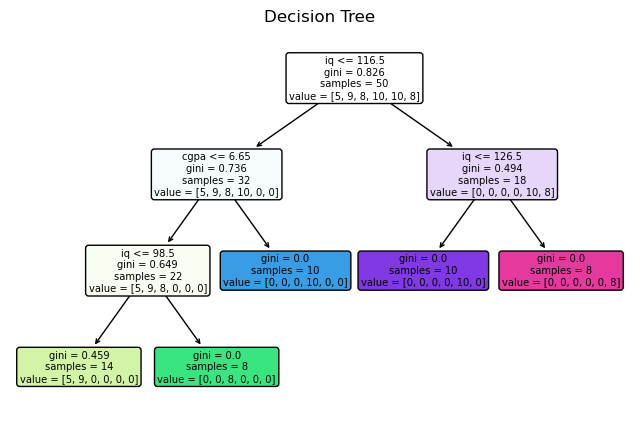

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plot_tree(
    clf,
    filled=True,
    feature_names=X.columns,
    rounded=True
)
plt.title("Decision Tree")
# plt.savefig("dt.png")
plt.show()

In [12]:
model_xgr = XGBRegressor(n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42)

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train_xgr,X_test_xgr,y_train_xgr,y_test_xgr = train_test_split(X,y,test_size=0.2,random_state = 42)

In [15]:
model_xgr.fit(X_train_xgr,y_train_xgr)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [16]:
y_pred_xgr = model_xgr.predict(X_test_xgr)

In [17]:
print(f"MSE : {mean_squared_error(y_test_xgr,y_pred_xgr)}")

MSE : 1.3811305734634516e-07


In [18]:
y_pred_xgr

array([4.000047 , 6.9994817, 2.0007136, 5.000004 , 5.99986  , 6.9994817,
       5.99986  , 5.000004 , 3.0001562, 6.9994817], dtype=float32)

In [19]:
#predict on new unseen data

In [20]:
nw = pd.DataFrame({
    "iq":[190],
    "cgpa":[9.9] 
})

In [21]:
predictions = model_xgr.predict(nw)
print(predictions)

[6.9994817]


In [22]:
#spam classifer using xgboostclassifier

In [23]:
from xgboost import XGBClassifier
model_xgc = XGBClassifier(n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42)

In [24]:
emails_xgc = [
    # 20 Spam (1)
    "Win a brand new car today",
    "Get 70% off on all products",
    "Claim your free vacation now",
    "Congratulations! You are a winner",
    "Limited offer: Buy one get one free",
    "Earn $5000 working from home",
    "Exclusive prize for lucky users",
    "Click here to unlock your reward",
    "Urgent: Respond to claim your gift",
    "Lowest prices on electronics today",
    "Hot deals: Save big now",
    "Double your income in one week",
    "Free entry to the lucky draw",
    "Get rich quick with this plan",
    "Special discount just for you",
    "Immediate loan approval available",
    "Claim your free voucher today",
    "Winner! Your reward is waiting",
    "Act fast to get limited bonus",
    "Cash prize waiting to be claimed",

    # 20 Not Spam (0)
    "Team meeting rescheduled to Monday",
    "Your flight itinerary for next week",
    "Project update: please review attached files",
    "Lunch with the client confirmed",
    "Reminder: submit the report by today",
    "Your subscription has been renewed",
    "Can we move the meeting to 3 PM?",
    "Minutes of the last team meeting attached",
    "Your application status has been updated",
    "Happy anniversary wishes",
    "Conference agenda for tomorrow",
    "Invoice for last month attached",
    "Doctor appointment confirmation",
    "Please review the attached proposal",
    "Family gathering this weekend",
    "Your order has been delivered",
    "Invitation to the company seminar",
    "Weekly performance report attached",
    "Your package is out for delivery",
    "Schedule your interview for next week"
]

labels_xgc = [
    # Spam
    1,1,1,1,1,1,1,1,1,1,
    1,1,1,1,1,1,1,1,1,1,

    # Not Spam
    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0
]


In [25]:
xgc_emails = vect.fit_transform(emails)

NameError: name 'vect' is not defined

In [415]:
X_train_xgc,X_test_xgc,y_train_xgc,y_test_xgc = train_test_split(xgc_emails,labels_xgc,test_size=0.2,random_state=42)

In [416]:
model_xgc.fit(X_train_xgc,y_train_xgc)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [424]:
y_pred_xgc = model_xgc.predict(X_test_xgc)

In [425]:
y_pred_xgc

array([0, 1, 1, 1, 1, 1, 1, 1])

In [426]:
y_test_xgc

[1, 1, 1, 0, 1, 1, 0, 0]

In [427]:
y_pred_xgc

array([0, 1, 1, 1, 1, 1, 1, 1])

In [428]:
print(classification_report(y_test_xgc,y_pred_xgc))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.57      0.80      0.67         5

    accuracy                           0.50         8
   macro avg       0.29      0.40      0.33         8
weighted avg       0.36      0.50      0.42         8

